In [1]:
import numpy as np, pandas as pd

from sklearn.tree import DecisionTreeClassifier
cols = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI',
        'DiabetesPedigreeFunction','Age','Outcome']
df = pd.read_csv('C:/medicalAI/Pycham/week3/Data_processing/pima-indians-diabetes.csv', names=cols)
#Glucose: 혈장 농도, insulin: 혈액의 2시간 혈청 인슐리 농도
#DiabetsPedigreeFunction: 가족친척의 당뇨병 이력 수치화, BMI: normal:18.5-22.9
#outcome: 0[당뇨병], 1[정상]

In [2]:
x= df.drop(columns='Outcome')
y= df['Outcome'].values
class_names = ['negative', 'diabets'] #0, 1


In [3]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
#1.prepare data
x_tr, x_te, y_tr, y_te = train_test_split(x, y, test_size=0.3, 
                                         random_state=42, stratify=y)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f'patient:{len(df)} / diabets rate:{100*y.mean():.2f}, train:{len(x_tr)}, test:{len(x_te)}')



patient:768 / diabets rate:34.90, train:537, test:231


In [4]:
#2.prepare model
from sklearn. preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV
models = {
    'LR': make_pipeline(StandardScaler(), LogisticRegression()), 
    'KNN':make_pipeline(StandardScaler(), KNeighborsClassifier()),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Boosting': GradientBoostingClassifier(),
    'SVM': make_pipeline(StandardScaler(), CalibratedClassifierCV(SVC(), ensemble=False))}


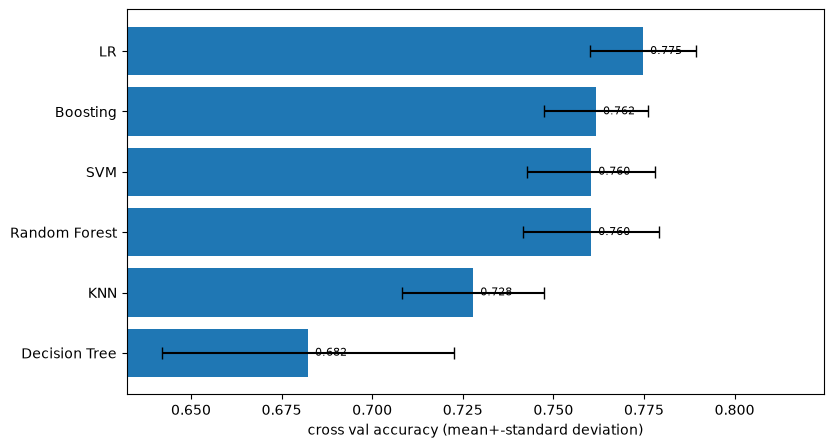

In [5]:
import matplotlib.pyplot as plt
#3.Cross Validation (5-fold CV)
cv_scores = {name : cross_val_score(m, x, y, cv=cv, scoring='accuracy')
            for name, m in models.items()}
cv_mean = {n:s.mean() for n, s in cv_scores.items()}
order = sorted(cv_mean, key=cv_mean.get)
plt.figure(figsize=(9, 5))
plt.barh(order, [cv_mean[n] for n in order], xerr=[cv_scores[n].std() for n in order], capsize=4)
lo = min(cv_mean.values()) - 0.05
plt.xlim(max(0, lo), min(1.0, max(cv_mean.values())+0.05))
plt.xlabel('cross val accuracy (mean+-standard deviation)')
for i, n in enumerate(order):
    plt.text(cv_mean[n]+0.002, i, f'{cv_mean[n]:.3f}', va='center', fontsize=8)
plt.savefig('cv_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()


In [6]:
#4.test data -> Multi-metric Evaluation 
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score)
rows = []
for name, m in models.items():
    m.fit(x_tr, y_tr)
    pred = m.predict(x_te)
    proba = m.predict_proba(x_te)[:, 1]
    rows.append({
        'model':name, 'accuracy': accuracy_score(y_te, pred),
        'precision':precision_score(y_te, pred), 'recall': recall_score(y_te, pred),
        'F1': f1_score(y_te, pred), 'AUC':roc_auc_score(y_te, proba)
    })
report = pd.DataFrame(rows).set_index('model').round(3).sort_values('AUC', ascending=False)
report


,accuracy,precision,recall,F1,AUC
model,,,,,
LR,0.745,0.677,0.519,0.587,0.838
Boosting,0.758,0.698,0.543,0.611,0.837
Random Forest,0.758,0.698,0.543,0.611,0.828
SVM,0.753,0.688,0.543,0.607,0.811
KNN,0.714,0.615,0.494,0.548,0.760
Decision Tree,0.784,0.731,0.605,0.662,0.742


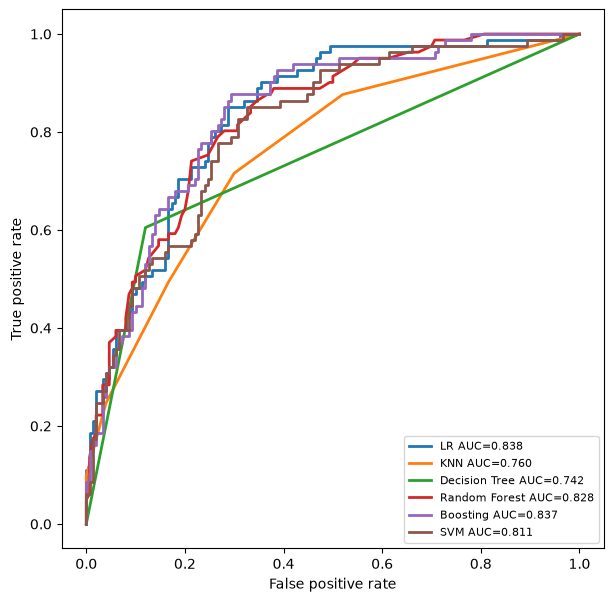

In [7]:
#5.compare Roc curve
from sklearn.metrics import roc_curve
plt.figure(figsize=(7, 7))
for name, m in models.items():
    proba = m.predict_proba(x_te)[:,1]
    fpr, tpr, _= roc_curve(y_te, proba)
    auc = roc_auc_score(y_te, proba)
    plt.plot(fpr, tpr, lw=2, label=f'{name} AUC={auc:.3f}')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.legend(fontsize=8)
plt.savefig('ROC.png', dpi=150, bbox_inches='tight')
plt.show()